In [1]:
import sys
import os

parent_dir = os.path.abspath("..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from sourceCode.decisionTree.decisiontree import DecisionTreeRegressor as ScratchDT

In [2]:
#Here I try to fit my Decision Tree to training data
from sklearn.tree import DecisionTreeRegressor as DT
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import numpy as np

In [29]:
df = pd.read_csv(r"..\data\claims_train_final.csv")
df.drop("Area",axis=1,inplace=True)
#df = pd.get_dummies(df,columns=["Region","VehBrand"],dtype=int)

In [30]:
fuel_map = {'Regular': 0, 'Diesel': 1}

df['VehGas'] = df['VehGas'].map(fuel_map)

In [31]:
x = df.drop(columns=["ClaimNb","Region","VehBrand"])
y = df["ClaimNb"]


In [32]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [33]:
dt = DecisionTreeRegressor(max_depth=5,max_leaf_nodes=29,min_samples_split=70,rss_loss=False)
dt.fit(x_train,y_train)


In [34]:
prediction = dt.predict(x_test)

In [35]:
y_test = y_test.to_numpy()

In [36]:
y_test = np.clip(y_test,0.0000000001,100)

In [37]:
prediction = np.clip(prediction,0.0000000001,100)

In [39]:
from sklearn.metrics import mean_poisson_deviance
from sklearn.metrics import d2_tweedie_score

def r_squared(model,truth):
    predictions_np = np.array(model)
    true_label_np = np.array(truth)
    TSS = np.sum((true_label_np - np.mean(true_label_np))**2)
    RSS = np.sum((predictions_np - true_label_np)**2)
    return (TSS - RSS)/TSS

def d_squared(model,truth):
    d_model = mean_poisson_deviance(truth,model)

    global_mean = np.mean(truth)
    y_null = np.full(len(truth), global_mean)
    d_null = mean_poisson_deviance(truth, y_null)

    return 1 - (d_model / d_null)


#r2_score(y_test,prediction)
#r2_score(y_train,prediction_s)
#d_squared(prediction,y_test)
#d2_tweedie_score(y_test,prediction,power=1)

0.023829125551274477

In [1]:
from sourceCode.decisionTree.decisiontree import DecisionTreeRegressor as DecesionTree_scratch
from sklearn.tree import DecisionTreeRegressor
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

def run_DT(training_data:pd.DataFrame,scratch=True):
    if scratch == True:
        dt = DecesionTree_scratch(max_depth=5,min_sample_split=100,rss_loss=True)
    else: 
        dt = DecisionTreeRegressor()

    Y = training_data["ClaimNb"]
    X = training_data.drop(columns="ClaimNb")
    X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)
    dt.fit(X_train,Y_train)
    predictions = dt.predict(X_test)
    return predictions, Y_test

def r_squared(predictions,true_label):
    predictions_np = np.array(predictions)
    true_label_np = np.array(true_label)
    TSS = np.sum((true_label_np - np.mean(true_label_np))**2)
    RSS = np.sum((predictions_np - true_label_np)**2)
    return (TSS - RSS)/TSS

def cross_validation():
    pass



In [56]:
x = x.to_numpy()
y = y.to_numpy()
dt = DecisionTreeRegressor(max_depth=4)
dt.fit(x,y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [32]:
from sklearn.metrics import r2_score
df = pd.read_csv(r"data\claims_train_scaled.csv")
x = df.drop(columns=["ClaimNb","VehGas","VehBrand","Region","Area"])
y = df["ClaimNb"]
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
dt = SK(max_depth=5,max_leaf_nodes=20)
dt.fit(x_train,y_train)
prediction = dt.predict(x_test)
print(r_squared(prediction, y_test))
r2_score(y_test,prediction)

0.019674129206013927


0.01967412920601397

In [13]:
from sklearn.tree import DecisionTreeRegressor as SK
from sklearn.model_selection import KFold
df = pd.read_csv(r"data\claims_train_scaled.csv")

df = df.drop(columns=["VehGas","VehBrand","Region","Area"])
for j in range(10,100,5):
    kf = KFold(n_splits=5)
    R_Vals_sklearn = []
    print(f"Max Depth = {j}")
    for i, (train_index, test_index) in enumerate(kf.split(df)):
        #print(f"Fold {i}:")
        df_train = df.iloc[train_index]
        df_test = df.iloc[test_index]
        dt = SK(min_samples_split=j)
        dt.fit(df_train.drop("ClaimNb",axis=1),df_train["ClaimNb"])
        predictions = dt.predict(df_test.drop("ClaimNb",axis=1))
        r = r_squared(predictions,df_test["ClaimNb"])
        R_Vals_sklearn.append(r)
    print(f"For max samples = {j} the average R Squared Value is {np.mean(R_Vals_sklearn)}")
        

Max Depth = 10
For max samples = 10 the average R Squared Value is -0.5147707171872978
Max Depth = 15
For max samples = 15 the average R Squared Value is -0.37640390726119516
Max Depth = 20
For max samples = 20 the average R Squared Value is -0.30083484158876705
Max Depth = 25
For max samples = 25 the average R Squared Value is -0.2517256073572138
Max Depth = 30
For max samples = 30 the average R Squared Value is -0.21703590051373153
Max Depth = 35
For max samples = 35 the average R Squared Value is -0.19099719650543348
Max Depth = 40
For max samples = 40 the average R Squared Value is -0.17041534849703685
Max Depth = 45
For max samples = 45 the average R Squared Value is -0.15242870026868546
Max Depth = 50
For max samples = 50 the average R Squared Value is -0.13781559719106526
Max Depth = 55
For max samples = 55 the average R Squared Value is -0.1253622269199405
Max Depth = 60
For max samples = 60 the average R Squared Value is -0.1145909495606009
Max Depth = 65
For max samples = 65 

In [21]:
R_Vals_sklearn

[np.float64(0.01708454006548034),
 np.float64(0.019721219856935385),
 np.float64(0.02003099696308602),
 np.float64(0.017947846640722277),
 np.float64(0.01998720634454142)]

In [11]:
#using pca scores to fit DT
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
df = pd.read_csv(r"data\claims_train_scaled.csv")
df_new = df.drop(columns=["VehGas","VehBrand","Region","Area","ClaimNb"])
pca_claims = PCA()
pca_claims.fit(df_new)
scores = pca_claims.transform(df_new)
df_pca = pd.DataFrame(scores)


Text(0, 0.5, 'Cummalative Sum of Explained Variance')

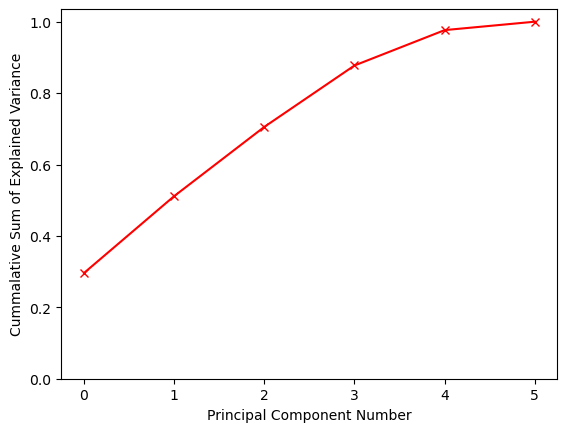

In [80]:
#explained variance
explained_var = pca_claims.explained_variance_ratio_
cum_sum = np.cumsum(explained_var)
plt.plot(range(len(cum_sum)),cum_sum,marker="x",c="red")
plt.ylim(0)
plt.xlabel("Principal Component Number")
plt.ylabel("Cummalative Sum of Explained Variance")


In [118]:
from sklearn.model_selection import KFold

df = pd.read_csv(r"..\data\claims_train_final.csv")
df.drop("Area",axis=1,inplace=True)
df = pd.get_dummies(df,columns=["Region","VehBrand"],dtype=int)
fuel_map = {'Regular': 0, 'Diesel': 1}
df['VehGas'] = df['VehGas'].map(fuel_map)

kf = KFold(n_splits=5)
d2_scores = []
for i, (train_index, test_index) in enumerate(kf.split(df)):
    print(f"Fold {i}:")
    df_train = df.iloc[train_index]
    df_target_train = df.iloc[train_index]
    df_test = df.iloc[test_index]
    df_target_test = df.iloc[test_index]
    dt = ScratchDT(max_depth=5,max_leaf_nodes=29,min_samples_split=70,rss_loss=False)
    dt.fit(df_train.drop("ClaimNb",axis=1),df_target_train["ClaimNb"])
    predictions = dt.predict(df_test.drop("ClaimNb",axis=1))
    d = d2_tweedie_score(df_target_test["ClaimNb"],predictions,power=1)
    d2_scores.append(d)
    print(d)
print(f"The average score d squared score is {np.mean(d2_scores)}")
    

Fold 0:
0.061144160175608864
Fold 1:
0.068043908503724
Fold 2:
0.06826673600179589
Fold 3:
0.063761274750753
Fold 4:
0.0636547289215127
The average score d squared score is 0.06497416167067889


In [27]:
for j in range(2,32,5):
    kf = KFold(n_splits=5)
    Avg_r_vals = {i:0 for i in range(j)}
    print(f"Max Depth = {j}")
    for i, (train_index, test_index) in enumerate(kf.split(df_pca)):
        R_Vals_sklearn = []
        #print(f"Fold {i}:")
        df_train = df_pca.iloc[train_index]
        df_target_train = df.iloc[train_index]
        df_test = df_pca.iloc[test_index]
        df_target_test = df.iloc[test_index]
        dt = SK(max_leaf_nodes=j)
        dt.fit(df_train,df_target_train["ClaimNb"])
        predictions = dt.predict(df_test)
        r = r_squared(predictions,df_target_test["ClaimNb"])
        R_Vals_sklearn.append(r)
    print(f"For max samples = {j} the average R Squared Value is {np.mean(R_Vals_sklearn)}")
    Avg_r_vals[j] = np.mean(R_Vals_sklearn) 

print(Avg_r_vals)

Max Depth = 2
For max samples = 2 the average R Squared Value is 0.004655326983205001
Max Depth = 7
For max samples = 7 the average R Squared Value is 0.012476897376257927
Max Depth = 12
For max samples = 12 the average R Squared Value is 0.014297619706104776
Max Depth = 17
For max samples = 17 the average R Squared Value is 0.015558176081808425
Max Depth = 22
For max samples = 22 the average R Squared Value is 0.016252195308454558
Max Depth = 27
For max samples = 27 the average R Squared Value is 0.01587552127672919
{0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0, 11: 0, 12: 0, 13: 0, 14: 0, 15: 0, 16: 0, 17: 0, 18: 0, 19: 0, 20: 0, 21: 0, 22: 0, 23: 0, 24: 0, 25: 0, 26: 0, 27: np.float64(0.01587552127672919)}


Text(0.5, 1.0, 'Averge R-Squared using KFold vs Max Leaf Nodes')

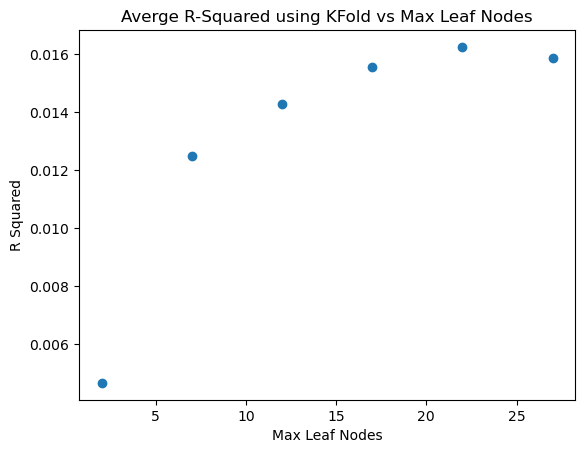

In [34]:
vals = {2:0.004655326983205001,7:0.012476897376257927,12:0.014297619706104776,17:0.015558176081808425,22:0.016252195308454558,27:0.01587552127672919}
plt.scatter(vals.keys(),vals.values())
plt.xlabel("Max Leaf Nodes")
plt.ylabel("R Squared")
plt.title("Averge R-Squared using KFold vs Max Leaf Nodes")

Text(0, 0.5, 'R Squared')

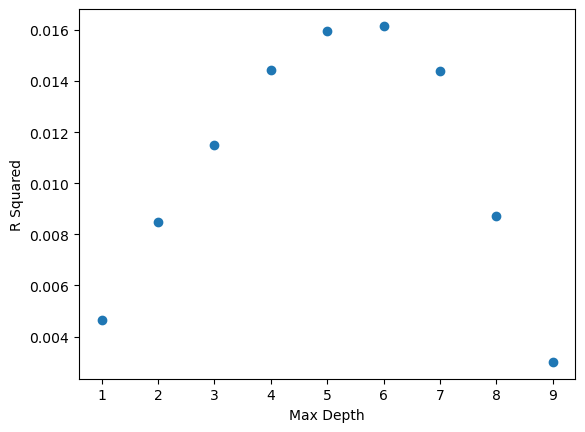

In [24]:
vals = {1:0.004655326983205001,2:0.008488118515138279,3:0.011488323019566857,4:0.014442610435605572,5:0.01594074183634016,6:0.016155793723355107,7:0.014384521083490382,8:0.008713323261855822,9:0.0030099698534020837}
plt.scatter(vals.keys(),vals.values())
plt.xlabel("Max Depth")
plt.ylabel("R Squared")
plt.title("Averge R-Squared using KFold vs Max Depth")

In [9]:
#RandomSearch 
from sklearn.model_selection import RandomizedSearchCV

param_dict = {
    'max_depth': [int(x) for x in range(1,10)],
    'max_leaf_nodes' : [int(x) for x in range(1,30,2)],
    'min_samples_split' : [int(x) for x in range(10,120,10)]
}

dt_classifier = DecisionTreeRegressor(rss_loss=False)

random_search = RandomizedSearchCV(
    estimator=dt_classifier,
    param_distributions=param_dict,
    n_iter=100,  # Number of parameter settings that are sampled
    cv=5,  # Number of cross-validation folds
    verbose=2,
    scoring="r2",
    random_state=42,
    n_jobs=-1  # Use all available processors
)


In [10]:
df = pd.read_csv(r"..\data\claims_train_final.csv")
df.drop("Area",axis=1,inplace=True)

fuel_map = {'Regular': 0, 'Diesel': 1}

df['VehGas'] = df['VehGas'].map(fuel_map)

x = df.drop(columns=["ClaimNb","Region","VehBrand"])
y = df["ClaimNb"]

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
random_search.fit(x_train,y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,estimator,DecisionTreeR...ss_loss=False)
,param_distributions,"{'max_depth': [1, 2, ...], 'max_leaf_nodes': [1, 3, ...], 'min_samples_split': [10, 20, ...]}"
,n_iter,100
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [ ]:
# Retrieve the best parameters found by RandomizedSearchCV
best_params = random_search.best_params_
print("Best Parameters:", best_params)

# Evaluate the model with best parameters on the test set
best_estimator = random_search.best_estimator_
test_accuracy = best_estimator.score(x_test, y_test)
print("Test r2 with Best Parameters:", test_accuracy)

Best Parameters: {'min_samples_split': 70, 'max_leaf_nodes': 29, 'max_depth': 5}
Test r2 with Best Parameters: 0.02388308129825445


In [26]:
results_df = pd.DataFrame(random_search.cv_results_)
results_df.to_csv(r"C:\Users\khatt\Desktop\MLProject-Group-SR\data\randomsearchCV_resultDT.csv")

In [12]:
results_df.sort_values(by=["rank_test_score"])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_min_samples_split,param_max_leaf_nodes,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
57,17.102482,0.753798,11.044999,0.476839,70,29,5,"{'min_samples_split': 70, 'max_leaf_nodes': 29...",0.022252,0.021009,0.024700,0.023967,0.024225,0.023230,0.001385,1
32,18.099654,0.553084,11.038293,0.848818,70,25,5,"{'min_samples_split': 70, 'max_leaf_nodes': 25...",0.022121,0.020082,0.023664,0.023746,0.024015,0.022725,0.001479,2
59,16.670224,0.779523,10.884513,0.215476,20,25,5,"{'min_samples_split': 20, 'max_leaf_nodes': 25...",0.022121,0.020082,0.023664,0.023746,0.024015,0.022725,0.001479,2
37,17.632486,0.700733,10.897410,0.225003,10,23,5,"{'min_samples_split': 10, 'max_leaf_nodes': 23...",0.021061,0.019199,0.022249,0.022490,0.023027,0.021605,0.001364,4
26,13.749208,0.742114,10.890974,0.376387,90,19,4,"{'min_samples_split': 90, 'max_leaf_nodes': 19...",0.018664,0.017957,0.021992,0.020880,0.020955,0.020089,0.001521,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46,4.418457,0.192033,9.117553,0.227034,80,9,1,"{'min_samples_split': 80, 'max_leaf_nodes': 9,...",0.003650,0.004284,0.003683,0.004289,0.004483,0.004078,0.000344,88
74,4.622533,0.598995,8.548351,0.301135,80,5,1,"{'min_samples_split': 80, 'max_leaf_nodes': 5,...",0.003650,0.004284,0.003683,0.004289,0.004483,0.004078,0.000344,88
39,4.622034,0.087896,8.096791,0.168000,60,21,1,"{'min_samples_split': 60, 'max_leaf_nodes': 21...",0.003650,0.004284,0.003683,0.004289,0.004483,0.004078,0.000344,88
9,3.456954,0.435302,5.765872,0.185239,60,9,1,"{'min_samples_split': 60, 'max_leaf_nodes': 9,...",0.003650,0.004284,0.003683,0.004289,0.004483,0.004078,0.000344,88


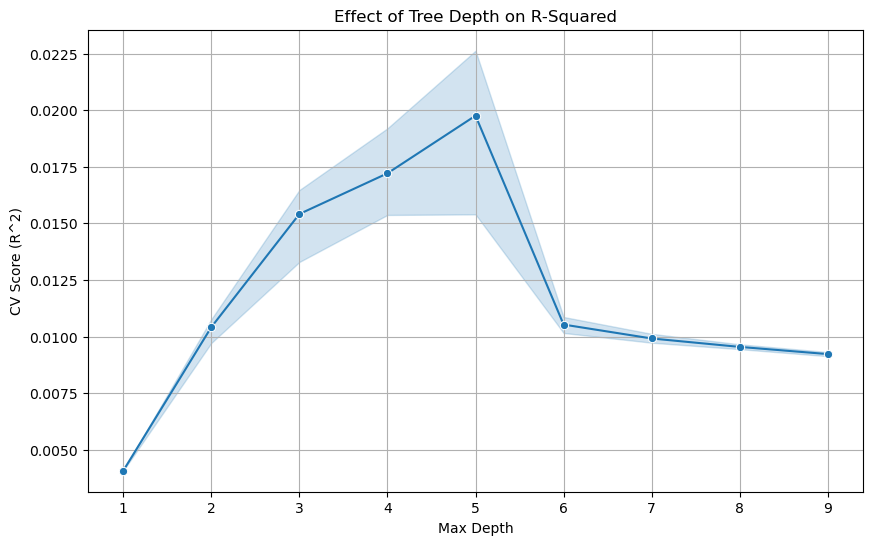

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort values to make the line look nice
results_df = results_df.sort_values(by='param_max_depth')

plt.figure(figsize=(10, 6))
sns.lineplot(data=results_df, x='param_max_depth', y='mean_test_score', marker='o')

plt.title("Effect of Tree Depth on R-Squared")
plt.xlabel("Max Depth")
plt.ylabel("CV Score (R^2)")
plt.grid(True)
plt.show()

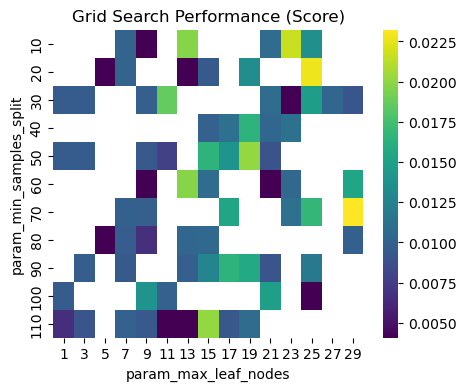

In [25]:
# Pivot the data for a heatmap: 
# Index=Depth, Columns=Min_Samples, Values=Score
pivot_table = results_df.pivot_table(
    values='mean_test_score', 
    index='param_min_samples_split', 
    columns='param_max_leaf_nodes'
)

plt.figure(figsize=(5, 4))
sns.heatmap(pivot_table, annot=False, cmap='viridis', fmt=".3f")
plt.title("Grid Search Performance (Score)")
plt.show()

In [8]:
from sklearn.metrics import d2_tweedie_score

In [41]:
#DECESION TREE FINAL RUN
df_train = pd.read_csv(r"..\data\claims_train_scaled.csv")
df_test = pd.read_csv(r"..\data\claims_test_final.csv")


In [47]:
np.mean(df_train["ClaimNb"])

np.float64(0.05312412202226921)

In [46]:
np.var(df_train["ClaimNb"])

0.057015244667290556

In [4]:
x_train = df_train.drop("ClaimNb",axis=1)

fuel_map = {'Regular': 0, 'Diesel': 1}
x_train['VehGas'] = x_train['VehGas'].map(fuel_map)
x_train = x_train.drop("Area",axis=1)

x_train = pd.get_dummies(x_train,columns=["Region","VehBrand"],dtype=int)

y_train = df_train["ClaimNb"]

In [5]:
x_test = df_test.drop("ClaimNb",axis=1)

fuel_map = {'Regular': 0, 'Diesel': 1}
x_test['VehGas'] = x_test['VehGas'].map(fuel_map)
x_test = x_test.drop("Area",axis=1)

x_test = pd.get_dummies(x_test,columns=["Region","VehBrand"],dtype=int)

y_test = df_test["ClaimNb"]

In [6]:
dt = ScratchDT(max_depth=5,max_leaf_nodes=29,min_samples_split=70,rss_loss=False)
dt.fit(x_train,y_train)

The best loss for this split was 170699.0740171311
The best loss for this split was 43277.84564214831
The best loss for this split was 10880.396416897456
The best loss for this split was 6517.869634668844
The best loss for this split was 612.0399230095616
The best loss for this split was 5819.257520969131
The best loss for this split was 3876.234856087522
The best loss for this split was 254.01304578529403
The best loss for this split was 3545.077320996277
The best loss for this split was 31152.524373928845
The best loss for this split was 9965.991944641471
The best loss for this split was 6816.081872046727
The best loss for this split was 3105.7987240540247
The best loss for this split was 20834.35583559482
The best loss for this split was 17482.00020017694
The best loss for this split was 3260.7573957531968
The best loss for this split was 124314.70597291572
The best loss for this split was 78655.36394908844
The best loss for this split was 5820.750684766457
The best loss for this sp

In [9]:
predictions = dt.predict(x_test)
d2_tweedie_score(y_test,predictions,power=1)

0.0682586015227169

In [11]:
from sklearn.metrics import mean_poisson_deviance
mean_poisson_deviance(y_test,predictions)

0.30191722540570165

0.9498277315273486

Text(0.5, 1.0, 'True vs Predicted Number of Claims on Test Data')

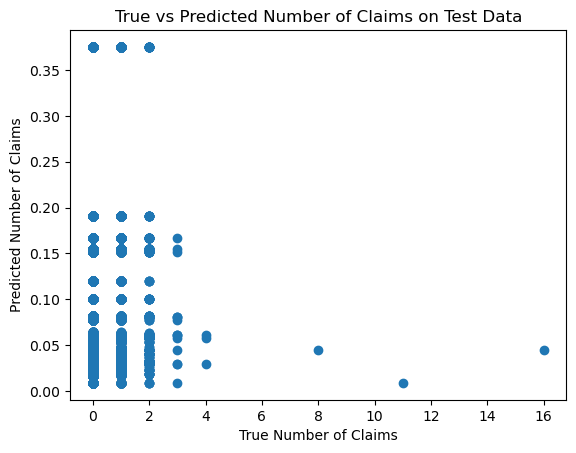

In [124]:
plt.scatter(y_test,predictions)
plt.xlabel("True Number of Claims")
plt.ylabel("Predicted Number of Claims")
plt.title("True vs Predicted Number of Claims on Test Data")

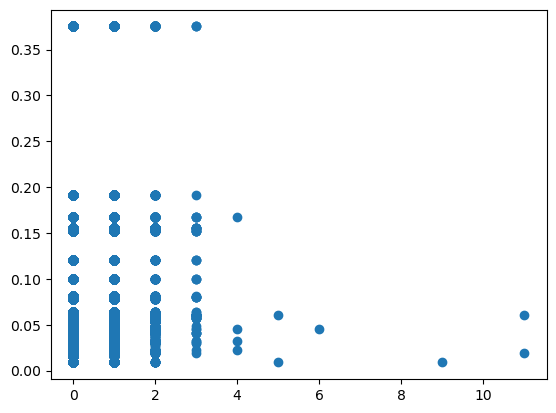

In [113]:
prediction_train = dt.predict(x_train)


Text(0.5, 1.0, 'True vs Predicted Number of Claims on Training Data')

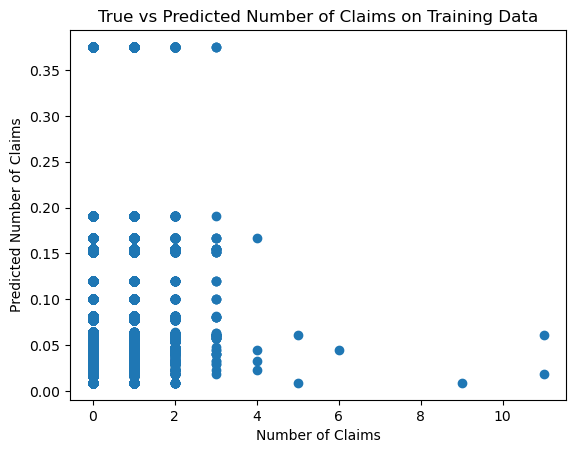

In [115]:
plt.scatter(y_train,prediction_train)
plt.xlabel("Number of Claims")
plt.ylabel("Predicted Number of Claims")
plt.title("True vs Predicted Number of Claims on Training Data")

(array([27381., 42197., 46976.,  8425.,  1306.,     0.,   882.,  4818.,
         2320.,   894.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,   404.]),
 array([0.00884544, 0.02716532, 0.0454852 , 0.06380508, 0.08212496,
        0.10044484, 0.11876472, 0.1370846 , 0.15540448, 0.17372436,
        0.19204424, 0.21036412, 0.22868399, 0.24700387, 0.26532375,
        0.28364363, 0.30196351, 0.32028339, 0.33860327, 0.35692315,
        0.37524303]),
 <BarContainer object of 20 artists>)

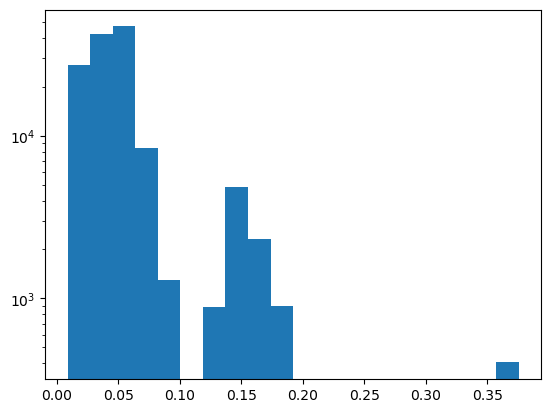

In [108]:
plt.hist(predictions,log=True,bins=20)

In [136]:
predictions = pd.DataFrame(predictions)
predictions.join(y_test)

,Predictions,ClaimNb
0,NaN,0
1,NaN,0
2,NaN,0
3,NaN,0
4,NaN,0
...,...,...
135598,NaN,0
135599,NaN,0
135600,NaN,0
135601,NaN,0


In [14]:
len(df_train[df_train["ClaimNb"] == 0])/len(df_train)
df_sampled = df_train[df_train["ClaimNb"] == 0].sample(frac=0.1)

In [19]:
non_zero = df_train[df_train["ClaimNb"] != 0]

In [20]:
df_samples = pd.concat([non_zero,df_sampled])

In [22]:
x_train = df_samples.drop("ClaimNb",axis=1)

fuel_map = {'Regular': 0, 'Diesel': 1}
x_train['VehGas'] = x_train['VehGas'].map(fuel_map)
x_train = x_train.drop("Area",axis=1)

x_train = pd.get_dummies(x_train,columns=["Region","VehBrand"],dtype=int)

y_train = df_samples["ClaimNb"]

In [ ]:
dt = ScratchDT(max_depth=5,max_leaf_nodes=29,min_samples_split=70,rss_loss=False)
dt.fit(x_train,y_train)

In [26]:
pred = dt.predict(x_test)


-1.4901245559986105

In [28]:
np.clip(pred)


array([0.39410381, 0.25029797, 0.57865169, ..., 0.31097114, 0.31097114,
       0.39410381], shape=(135603,))

In [35]:
y_test = y_test.to_numpy()

numpy.ndarray

array([0, 0, 0, ..., 0, 0, 0], shape=(135603,))

NameError: name 'df' is not defined